# CCGT NPV simulation

Run the CCGT electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_technology_npv,
)


In [2]:
TECHNOLOGY = 'ccgt'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_electricity_technology_npv(
    technology=TECHNOLOGY,
    size=SAMPLE_SIZE,
    rng=rng,
)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,ccgt,1000000.0,4650.0,215.053763,215053.763441,1209.582419,24.084901,5.004625,1.661379,...,94070000.0,5.179549e+06,5.004625e+06,8.396756e+07,2.686678e+07,-2.694851e+07,-5.477946e+08,25000000.0,-21.911783,-2.191178e-05
1,1,ccgt,1000000.0,4650.0,215.053763,215053.763441,1075.551376,24.227244,4.989683,1.657569,...,94070000.0,5.210160e+06,4.989683e+06,3.374190e+07,2.742797e+07,2.270029e+07,1.101915e+07,25000000.0,0.440766,4.407659e-07
2,2,ccgt,1000000.0,4650.0,215.053763,215053.763441,1243.439168,20.723677,5.796462,1.680755,...,94070000.0,4.456705e+06,5.796462e+06,6.207696e+07,2.694865e+07,-5.208781e+06,-3.230088e+08,25000000.0,-12.920354,-1.292035e-05
3,3,ccgt,1000000.0,4650.0,215.053763,215053.763441,1178.947212,19.167743,5.241452,1.678629,...,94070000.0,4.122095e+06,5.241452e+06,5.895616e+07,2.718905e+07,-1.438764e+06,-2.688955e+08,25000000.0,-10.755821,-1.075582e-05
4,4,ccgt,1000000.0,4650.0,215.053763,215053.763441,937.670939,22.045178,5.551210,1.679283,...,94070000.0,4.740899e+06,5.551210e+06,6.633035e+07,2.686496e+07,-9.417422e+06,-3.021785e+08,25000000.0,-12.087142,-1.208714e-05


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh
count,100000.000000,100000.000000
mean,-319.985863,-12.799435
std,252.925266,10.117011
min,-1234.777562,-49.391102
5%,-778.233148,-31.129326
50%,-293.925066,-11.757003
95%,47.651025,1.906041
max,195.855703,7.834228


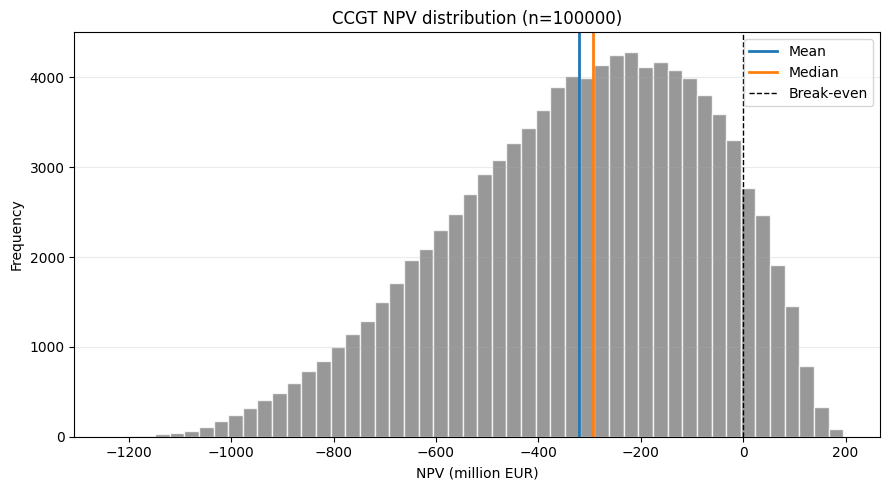

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


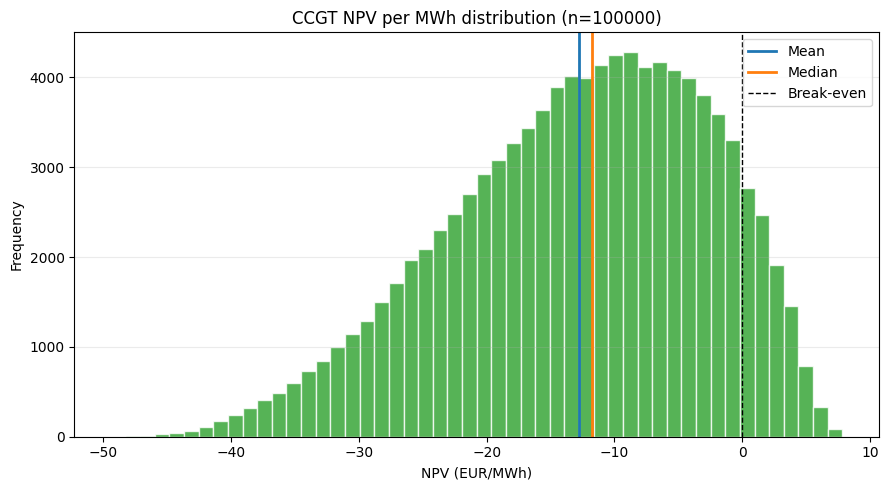

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         4.443818
annual_variable_opex_eur      5.167443
annual_fuel_cost_eur         65.311546
annual_emissions_cost_eur    26.957471
annual_net_cash_flow_eur     -7.810278
Name: Mean annual value, million EUR, dtype: float64